In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from mlxtend.plotting import plot_decision_regions


In [3]:
class GaussianNaiveBayes:
    def fit(self, X, y):
        classes, cls_counts = np.unique(y, return_counts=True)
        n_classes = len(classes)
        self.priors = cls_counts / len(y)

        # calculate the mean and standard deviations of features by classes
        self.X_cls_mean = np.array([np.mean(X[y == c], axis=0) for c in range(n_classes)])
        self.X_stds = np.array([np.std(X[y == c], axis=0) for c in range(n_classes)])

    # calculate the probability density of the feature according to the Gaussian distribution
    def pdf(self, x, mean, std):
        return (1 / (np.sqrt(2 * np.pi) * std)) * np.exp(-0.5 * ((x - mean) / std) ** 2)

    def predict(self, X):
        pdfs = np.array([self.pdf(x, self.X_cls_mean, self.X_stds) for x in X])
        posteriors = self.priors * np.prod(pdfs, axis=2)   # shorten Bayes formula

        return np.argmax(posteriors, axis=1)

In [4]:
def decision_boundary_plot(X, y, X_train, y_train, clf, feature_indexes, title=None):
    feature1_name, feature2_name = X.columns[feature_indexes]
    X_feature_columns = X.values[:, feature_indexes]
    X_train_feature_columns = X_train[:, feature_indexes]
    clf.fit(X_train_feature_columns, y_train)

    plot_decision_regions(X=X_feature_columns, y=y.values, clf=clf)
    plt.xlabel(feature1_name)
    plt.ylabel(feature2_name)
    plt.title(title)

In [15]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

iris = load_iris()
iris = pd.DataFrame(data=np.c_[iris.data, iris.target], columns=iris.feature_names + ['target'])
X, y = iris.iloc[:, :-1], iris.iloc[:, -1]
y = pd.Series(LabelEncoder().fit_transform(y))
X_train, X_test, y_train, y_test = train_test_split(X.values, y.values, random_state=42, test_size=0.2)
print(iris)

     sepal length (cm)  sepal width (cm)  ...  petal width (cm)  target
0                  5.1               3.5  ...               0.2     0.0
1                  4.9               3.0  ...               0.2     0.0
2                  4.7               3.2  ...               0.2     0.0
3                  4.6               3.1  ...               0.2     0.0
4                  5.0               3.6  ...               0.2     0.0
..                 ...               ...  ...               ...     ...
145                6.7               3.0  ...               2.3     2.0
146                6.3               2.5  ...               1.9     2.0
147                6.5               3.0  ...               2.0     2.0
148                6.2               3.4  ...               2.3     2.0
149                5.9               3.0  ...               1.8     2.0

[150 rows x 5 columns]


In [16]:
from sklearn.metrics import accuracy_score

nb = GaussianNaiveBayes()
nb.fit(X_train, y_train)
y_pred = nb.predict(X_test)

nb_accuracy = accuracy_score(y_test, y_pred)

print(f'Naive Bayes classifier accuracy: {nb_accuracy}')
print(y_pred)

Naive Bayes classifier accuracy: 1.0
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


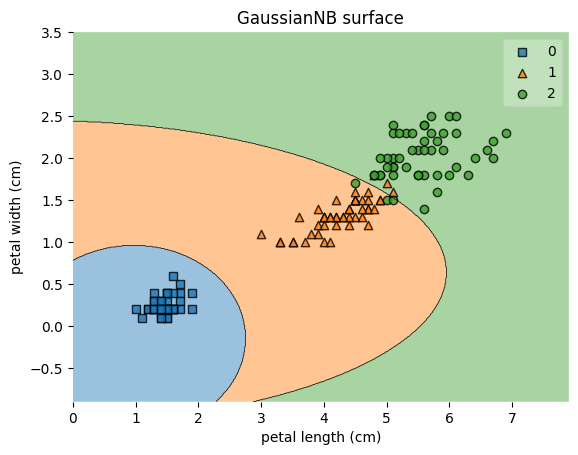

In [22]:
feature_indexes = [2, 3]
title1 = 'GaussianNB surface'
decision_boundary_plot(X, y, X_train, y_train, nb, feature_indexes, title1)